In [37]:
import os
import sys
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import pyarrow as pa
import polars as pl
import polars.selectors as cs

from matplotlib import pyplot as plt
from deltalake import DeltaTable, write_deltalake

from sklearn.preprocessing import StandardScaler


In [2]:
sys.path.append(str("/root/capsule/src/"))

# Load results from other notebooks

In [5]:
PATH = "../results/cellfeatures/exc_morph_features/"
exc_feat_df = pl.read_delta(PATH)

In [6]:
PATH = "../results/dataset/"
dataset_df = pl.read_delta(PATH)

In [7]:
PATH = "../results/dataitem/"
dataitem_df = pl.read_delta(PATH)

In [8]:
PATH = "../results/dataitem_dataset_association/"
di_ds_assoc_df = pl.read_delta(PATH)

In [9]:
PATH = "../results/cluster/"
cluster_df = pl.read_delta(PATH)

In [10]:
PATH = "../results/clustermembership/"
cluster_memb_df = pl.read_delta(PATH)

In [107]:
PATH = "../results/celltoclustermapping/"
cell_cluster_map_df = pl.read_delta(PATH)

In [108]:
cell_cluster_map_df.get_column("mapping_set").unique()

mapping_set
str
"""visp_inh_patchseq_ttype_mappin…"
"""visp_exc_patchseq_ttype_mappin…"
"""visp_exc_wnm_mettype_mapping"""


In [16]:
PATH = "../results/cellfeaturedefinition/visp_exc"
feat_def_df = pl.read_delta(PATH)

# Make and plot UMAP

In [50]:
# Get the feature value columns that don't have any null values
# (happens since WNM values don't have, e.g., diameter values and other values dependent on that)

feature_data = exc_feat_df[feat_def_df['id']]
feature_data = feature_data.select(col for col in feature_data if col.is_not_null().all())

In [52]:
scaled_data = StandardScaler().fit_transform(feature_data.to_numpy())

In [54]:
embedding = reducer.fit_transform(scaled_data)

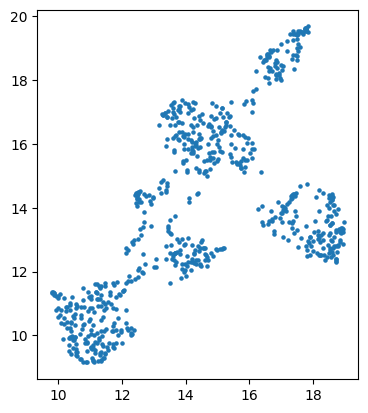

In [57]:
plt.scatter(*embedding.T, s=5)
plt.gca().set_aspect('equal')

In [133]:
# color by project
project_names = exc_feat_df.get_column("project_id").unique()
pal = sns.color_palette(n_colors=project_names.shape[0])

project_color_dict = dict(zip(project_names.to_list(), pal))

In [134]:
project_colors = [project_color_dict[project_id] for project_id in exc_feat_df.get_column("project_id")]

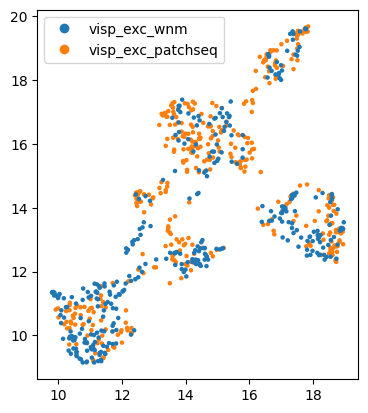

In [135]:
plt.scatter(*embedding.T, s=5, c=project_colors)
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in project_color_dict.values()]
plt.legend(markers, project_color_dict.keys(), numpoints=1)

plt.gca().set_aspect('equal')

In [136]:
# color by met-type

In [145]:
# Get cluster colors for patch-seq cells
ps_colors = exc_feat_df.join(
    cluster_memb_df, left_on="id", right_on="item", how="inner"
).select(["id", "cluster"]).join(
    cluster_df.filter(pl.col("heirachy_category") == "cluster"), left_on="cluster", right_on="id"
).select(["id", "hex_color"])

# Get cluster colors for wnm cells
wnm_colors = exc_feat_df.join(
    cell_cluster_map_df.filter(pl.col("mapping_set") == "visp_exc_wnm_mettype_mapping"),
    left_on="id", right_on="source_cell", how="inner"
).select(["id", "target_cluster"]).join(
    cluster_df.filter(pl.col("heirachy_category") == "cluster"), left_on="target_cluster", right_on="id"
).select(["id", "hex_color"])

all_colors = pl.concat([ps_colors, wnm_colors])

In [146]:
cluster_colors = exc_feat_df.join(all_colors, on="id", how="left").get_column("hex_color").to_numpy()

In [147]:
cluster_colors[cluster_colors == None] = "#333333"

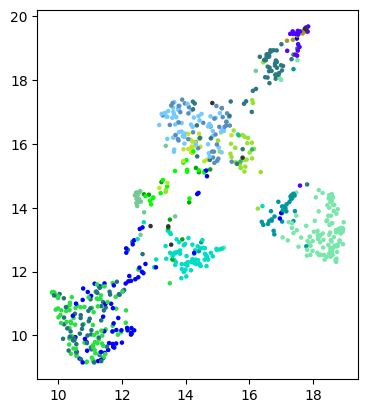

In [148]:
plt.scatter(*embedding.T, s=5, c=cluster_colors)
plt.gca().set_aspect('equal')